In [1]:
import numpy as np
import numpy.random as nprand
import matplotlib.pyplot as plt
from scipy.stats import gamma
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [ ]:
def f_1d(t):
    return np.sin(t)
def F(x,y,epsilon):
    return 0.5*(y-f_1d(x))**2 + 0.5*epsilon*x**2
def grad_F(x, y, epsilon):
    Fx = -(y - np.sin(x)) * np.cos(x) + epsilon * x
    Fy =  (y - np.sin(x))
    return Fx, Fy

def hess_F(x, y, eps):
    # Second derivative w.r.t x
    F_xx = np.cos(x)**2 - (y - np.sin(x))*np.sin(x) + eps
    
    # Mixed partials
    F_xy = -np.cos(x)
    F_yx = -np.cos(x)
    
    # Second derivative w.r.t y
    F_yy = 1.0
    
    H = np.array([
        [F_xx, F_xy],
        [F_yx, F_yy]
    ])
    return H

def hess_coeffs(x, y, eps):
    """
    Renvoie les coefficients a, b, c de la Hessienne 2x2 :
    H = [[a, b],
            [b, c]]
    pour F(x,y,eps) = 1/2 (y - sin x)^2 + 1/2 eps x^2
    """
    a = np.cos(x)**2 - (y - np.sin(x)) * np.sin(x) + eps
    b = -np.cos(x)
    c = 1.0
    return a, b, c

def eigen_value(x, y, eps):
    a,b,c = hess_coeffs(x, y, eps)
    trace = a + c
    delta = ((a - c) / 2)**2 + b**2
    sqrt_delta = np.sqrt(delta)

    lambda1 = trace / 2 + sqrt_delta
    lambda2 = trace / 2 - sqrt_delta

    # Plus grande valeur propre en valeur absolue
    lambda_max_abs = np.maximum(np.abs(lambda1), np.abs(lambda2))
    return lambda_max_abs

In [3]:
### L_smooth
epsilon = 0.001
x = np.linspace(-3*np.pi, 3*np.pi, 1000)
y = np.linspace(-3, 3, 1000)
L = 0
for i in x:
    for j in y:
        val = eigen_value(i, j, epsilon)
        L = max(L,val)
    # print("top :",i)

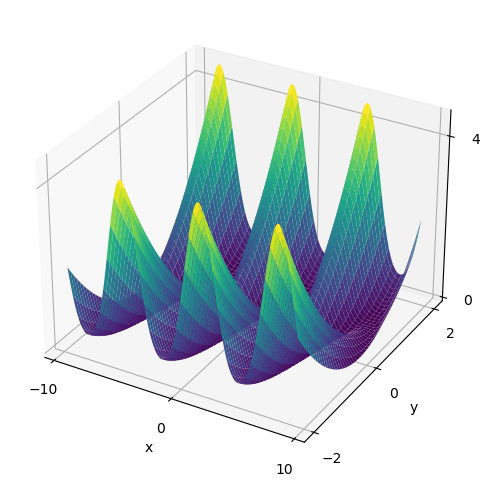

In [4]:
### PLOT ###

x = np.linspace(-3*np.pi, 3*np.pi, 400)
y = np.linspace(-2, 2, 400)
epsilon = 0.001
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)



fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xticks([-10,0,10])
ax.set_yticks([-2,0,2])
ax.set_zticks([0,4])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("F(x,y)")
# ax.set_title("Surface 3D de F(x,y) = 1/2 (y - sin(x))")
plt.show()


In [5]:
### ALGO ###



def gd(init,n_iter,stepsize):
    x_gd = np.empty((2,n_iter))
    f_gd = np.empty(n_iter)
    x_gd[:,0] = init
    f_gd[0] = F(x_gd[0,0],x_gd[1,0],epsilon)
    for i in range(1,n_iter):
        assign = grad_F(x_gd[0,i-1],x_gd[1,i-1],epsilon)
        grad = np.array([assign[0],assign[1]])
        x_gd[:,i] = x_gd[:,i-1] - (1/L)*grad
        f_gd[i] = F(x_gd[0,i],x_gd[1,i],epsilon)
    return x_gd,f_gd

def nag(init,n_iter,stepsize,alpha):

    x_nag = np.empty((2,n_iter))
    f_nag = np.empty(n_iter)
    corr = np.empty(n_iter)
    x_nag[:,0] = init
    x_prec = init
    f_nag[0] = F(x_nag[0,0],x_nag[1,0],epsilon)

    assign_corr = grad_F(x_nag[0,0],x_nag[1,0],epsilon)
    grad_corr = np.array([assign_corr[0],assign_corr[1]])
    norm_grad_corr = np.sqrt(np.sum(grad_corr**2))
    norm_x = np.sqrt(np.sum( x_nag[:,0]**2))
    corr[0] = np.sum(grad_corr*(x_nag[:,0]))/(norm_grad_corr*norm_x)
    corr = np.empty(n_iter)
    for i in range(1,n_iter):
        y_nag = x_nag[:,i-1] + alpha*(x_nag[:,i-1] - x_prec)
        assign_nag = grad_F(y_nag[0],y_nag[1],epsilon)
        grad_nag = np.array([assign_nag[0],assign_nag[1]])
        x_prec =  x_nag[:,i-1]
        x_nag[:,i] = y_nag - (1/L)*grad_nag
        f_nag[i] = F(x_nag[0,i],x_nag[1,i],epsilon)

        assign_corr = grad_F(x_nag[0,i],x_nag[1,i],epsilon)
        grad_corr = np.array([assign_corr[0],assign_corr[1]])
        norm_grad_corr = np.sqrt(np.sum(grad_corr**2))
        norm_x = np.sqrt(np.sum( x_nag[:,i]**2))
        corr[i] = np.sum(grad_corr*(x_nag[:,i]))/(norm_grad_corr*norm_x)
    return x_nag,f_nag,corr



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_27712/2385381261.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 600x600 with 0 Axes>

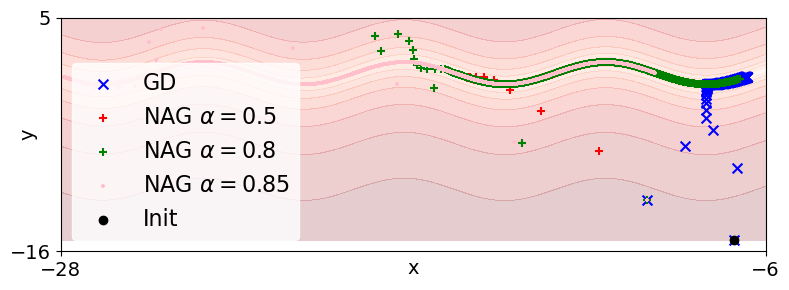

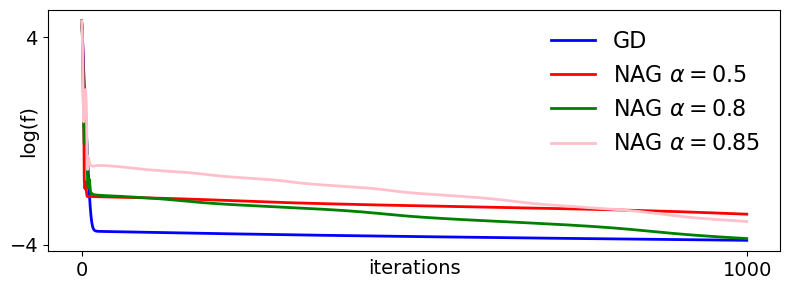

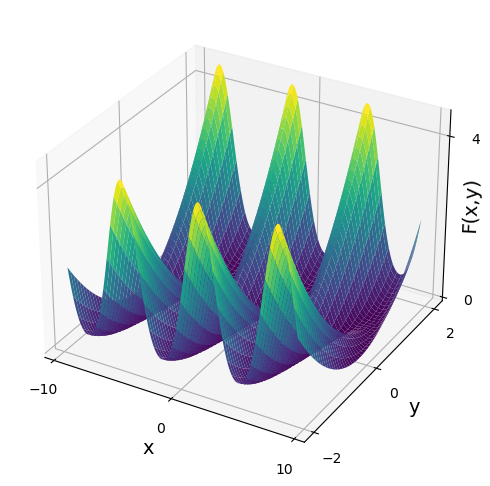

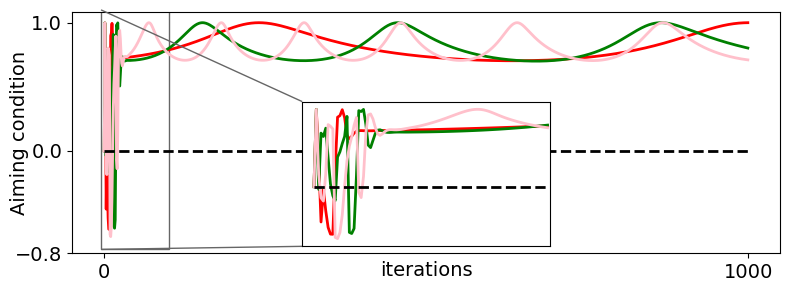

In [26]:
n_iter = 1*10**3
init =  np.array([-7,-15])
# init =  np.array([-10,-30])
x_gd,f_gd = gd(init,n_iter,1/L)
x_nag_0,f_nag_0,corr_0 = nag(init,n_iter,1/L,0.5)
x_nag_1,f_nag_1,corr_1 = nag(init,n_iter,1/L,0.8)
x_nag_2,f_nag_2,corr_2 = nag(init,n_iter,1/L,0.85)
# --- FIGURE 1 : scatter des trajectoires ---
fontsize = 14
fontsize_legend = 25
plt.figure(figsize=(6,6))



x = np.linspace(-28, -6, 400)
y = np.linspace(-15, 5, 400)
X, Y = np.meshgrid(x, y)
# U,V = grad_F(X, Y,epsilon)

Z = F(X, Y,epsilon)
# plt.quiver(X, Y, U, V, angles="xy", color="blue")

# norm_x2 = X**2 + Y**2
# norm_grad2 = U**2 + V**2

# mask = Z > 1e-12
# Q2 = np.zeros_like(X)
# Q2[mask] = norm_grad2[mask] / (2 * Z[mask])


# levels = np.concatenate([
#     np.linspace(0, 10, 10),   # zone dense autour de zéro
#     np.linspace(10, Z.max(), 10)
# ])
# levels_brut = np.linspace(0,1,20)
# levels = (levels_brut**4)*Z.max()
# # levels.reverse()

# for lev in levels:
#     # alpha augmente avec la valeur du niveau
#     # (tu peux ajuster la fonction pour obtenir l’effet que tu veux)
#     alpha = lev / levels.max()

#     plt.contour(X, Y, Z, levels=[lev],
#                 colors='black',
#                 linewidths=1.2,
#                 alpha=1-alpha)
plt.figure(figsize=(8,3))
fontsize_legend = 16
plt.contourf(X, Y, np.log(Z), levels=10, cmap="Reds",alpha = 0.2)

# plt.contour(X, Y, Z, levels=10, cmap="plasma")



plt.scatter(x_gd[0, :], x_gd[1, :], s=50,c="blue", label="GD",marker="x")
plt.scatter(x_nag_0[0, :], x_nag_0[1, :], s=40, label=r"NAG $\alpha = 0.5$", c='red',marker="+")
plt.scatter(x_nag_1[0, :], x_nag_1[1, :], s=30, label=r"NAG $\alpha = 0.8$", c='green',marker="+")
plt.scatter(x_nag_2[0, :], x_nag_2[1, :], s=10, label=r"NAG $\alpha = 0.85$", c='pink',marker="+")
plt.scatter(x_gd[0, 0], x_gd[1, 0],color="black",label="Init")
# plt.scatter(0, 0,color="yellow",label="Minimizer")
plt.xlabel("x",fontsize =fontsize,labelpad=-15)
plt.xticks([-28,-6],fontsize =fontsize)
plt.yticks([-16,5],fontsize =fontsize)
plt.ylabel("y",fontsize =fontsize,labelpad=-20)
# plt.title("Trajectoires GD vs NAG")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_traj.pdf", dpi=300, bbox_inches="tight")

# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(np.log(f_nag_0), label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(np.log(f_nag_1),label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(np.log(f_nag_2), label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
plt.xticks((0,1000),fontsize =fontsize)
plt.yticks((-4,4),fontsize =fontsize)
plt.ylabel("log(f)",fontsize =fontsize,labelpad=-20)
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_fonc.pdf", dpi=300, bbox_inches="tight")

x = np.linspace(-3*np.pi, 3*np.pi, 400)
y = np.linspace(-2, 2, 400)
epsilon = 0.001
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)



fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xticks([-10,0,10],fontsize =fontsize)
ax.set_yticks([-2,0,2],fontsize =fontsize)
ax.set_zticks([0,4],fontsize =fontsize)
ax.set_xlabel("x",fontsize =fontsize)
ax.set_ylabel("y",fontsize =fontsize)
ax.set_zlabel("F(x,y)",fontsize =fontsize,labelpad=-10)
plt.savefig("figures/toy_example_fig.pdf", dpi=300, bbox_inches="tight")


# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
# plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(corr_0[0:1000], label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(corr_1[0:1000],label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(corr_2[0:1000], label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
xx = np.arange(n_iter)
plt.plot(xx,np.zeros(n_iter)*xx,linestyle="--",color="black",lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
plt.xticks((0,1000),fontsize =fontsize)
plt.yticks((-0.8,0,1),fontsize =fontsize)
plt.ylabel("Aiming condition",fontsize =fontsize,labelpad=-10)
ax = plt.gca()  # axe principal
axins = inset_axes(ax, width="35%", height="60%", loc='lower center')

# Plot du zoom : 100 premières itérations
axins.plot(corr_0[:100],  c='red',  lw=2)
axins.plot(corr_1[:100],  c='green', lw=2)
axins.plot(corr_2[:100],  c='pink',  lw=2)
axins.plot(xx[:100],(np.zeros(n_iter)*xx)[:100],linestyle="--",color="black",lw=2)
# Définition du domaine du zoom
axins.set_xlim(-5, 100)
axins.set_ylim(min(corr_0[:100].min(), corr_1[:100].min(), corr_2[:100].min())-0.1,
               max(corr_0[:100].max(), corr_1[:100].max(), corr_2[:100].max())+0.1)

# Retirer les labels du zoom pour éviter le fouillis
axins.set_xticks([])
axins.set_yticks([])

# Petits traits reliant la fenêtre au graphe principal
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.4")
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_corr.pdf", dpi=300, bbox_inches="tight")



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_12040/3322812456.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


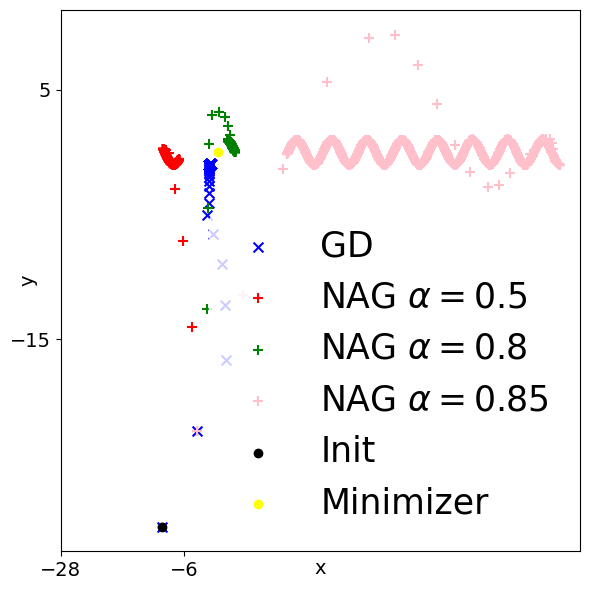

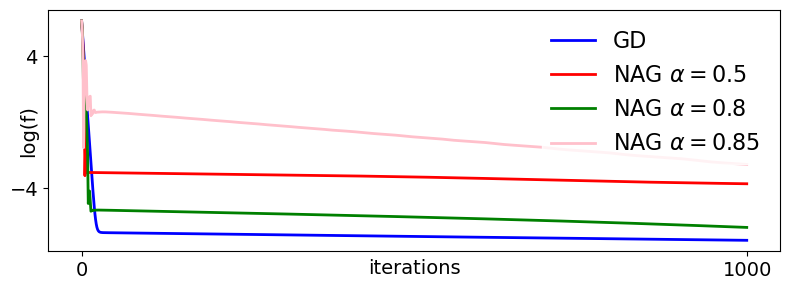

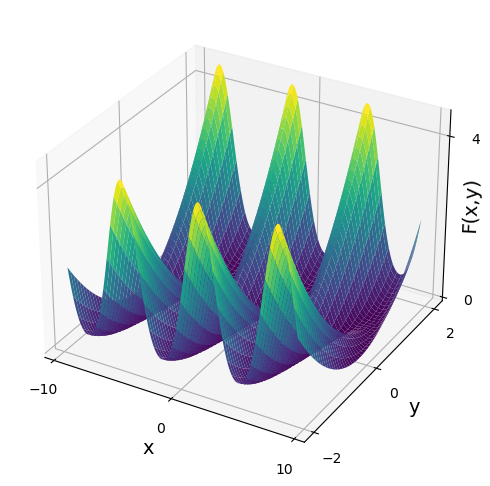

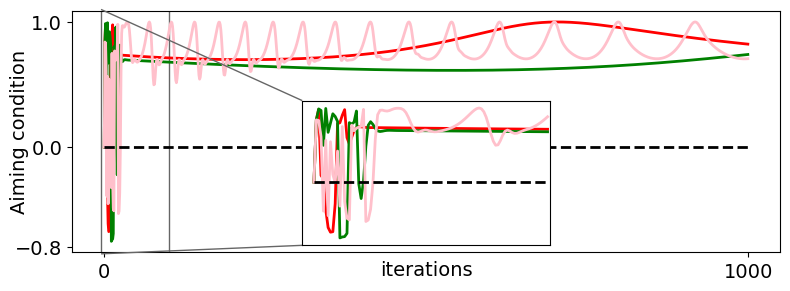

In [42]:
### Other try of initialization

n_iter = 1*10**3
# init =  np.array([-7,-15])
init =  np.array([-10,-30])
x_gd,f_gd = gd(init,n_iter,1/L)
x_nag_0,f_nag_0,corr_0 = nag(init,n_iter,1/L,0.5)
x_nag_1,f_nag_1,corr_1 = nag(init,n_iter,1/L,0.7)
x_nag_2,f_nag_2,corr_2 = nag(init,n_iter,1/L,0.9)
# --- FIGURE 1 : scatter des trajectoires ---
fontsize = 14
fontsize_legend = 25
plt.figure(figsize=(6,6))
plt.scatter(x_gd[0, :], x_gd[1, :], s=50,c="blue", label="GD",marker="x")
plt.scatter(x_nag_0[0, :], x_nag_0[1, :], s=60, label=r"NAG $\alpha = 0.5$", c='red',marker="+")
plt.scatter(x_nag_1[0, :], x_nag_1[1, :], s=60, label=r"NAG $\alpha = 0.8$", c='green',marker="+")
plt.scatter(x_nag_2[0, :], x_nag_2[1, :], s=60, label=r"NAG $\alpha = 0.85$", c='pink',marker="+")
plt.scatter(x_gd[0, 0], x_gd[1, 0],color="black",label="Init")
plt.scatter(0, 0,color="yellow",label="Minimizer")
plt.xlabel("x",fontsize =fontsize,labelpad=-15)
plt.xticks([-28,-6],fontsize =fontsize)
plt.yticks([-15,5],fontsize =fontsize)
plt.ylabel("y",fontsize =fontsize,labelpad=-20)
# plt.title("Trajectoires GD vs NAG")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_traj.pdf", dpi=300, bbox_inches="tight")

# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(np.log(f_nag_0), label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(np.log(f_nag_1),label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(np.log(f_nag_2), label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
plt.xticks((0,1000),fontsize =fontsize)
plt.yticks((-4,4),fontsize =fontsize)
plt.ylabel("log(f)",fontsize =fontsize,labelpad=-20)
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_fonc.pdf", dpi=300, bbox_inches="tight")

x = np.linspace(-3*np.pi, 3*np.pi, 400)
y = np.linspace(-2, 2, 400)
epsilon = 0.001
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)



fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xticks([-10,0,10],fontsize =fontsize)
ax.set_yticks([-2,0,2],fontsize =fontsize)
ax.set_zticks([0,4],fontsize =fontsize)
ax.set_xlabel("x",fontsize =fontsize)
ax.set_ylabel("y",fontsize =fontsize)
ax.set_zlabel("F(x,y)",fontsize =fontsize,labelpad=-10)
plt.savefig("figures/toy_example_fig.pdf", dpi=300, bbox_inches="tight")


# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
# plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(corr_0[0:1000], label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(corr_1[0:1000],label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(corr_2[0:1000], label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
xx = np.arange(n_iter)
plt.plot(xx,np.zeros(n_iter)*xx,linestyle="--",color="black",lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
plt.xticks((0,1000),fontsize =fontsize)
plt.yticks((-0.8,0,1),fontsize =fontsize)
plt.ylabel("Aiming condition",fontsize =fontsize,labelpad=-10)
ax = plt.gca()  # axe principal
axins = inset_axes(ax, width="35%", height="60%", loc='lower center')

# Plot du zoom : 100 premières itérations
axins.plot(corr_0[:100],  c='red',  lw=2)
axins.plot(corr_1[:100],  c='green', lw=2)
axins.plot(corr_2[:100],  c='pink',  lw=2)
axins.plot(xx[:100],(np.zeros(n_iter)*xx)[:100],linestyle="--",color="black",lw=2)
# Définition du domaine du zoom
axins.set_xlim(-5, 100)
axins.set_ylim(min(corr_0[:100].min(), corr_1[:100].min(), corr_2[:100].min())-0.1,
               max(corr_0[:100].max(), corr_1[:100].max(), corr_2[:100].max())+0.1)

# Retirer les labels du zoom pour éviter le fouillis
axins.set_xticks([])
axins.set_yticks([])

# Petits traits reliant la fenêtre au graphe principal
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.4")
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_corr.pdf", dpi=300, bbox_inches="tight")



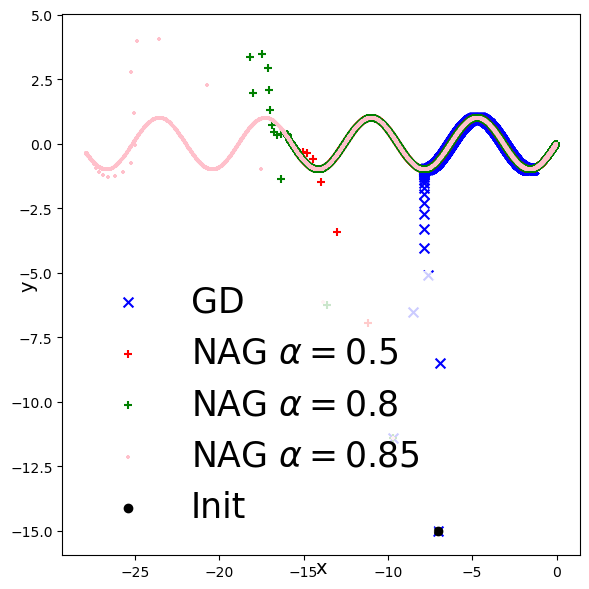

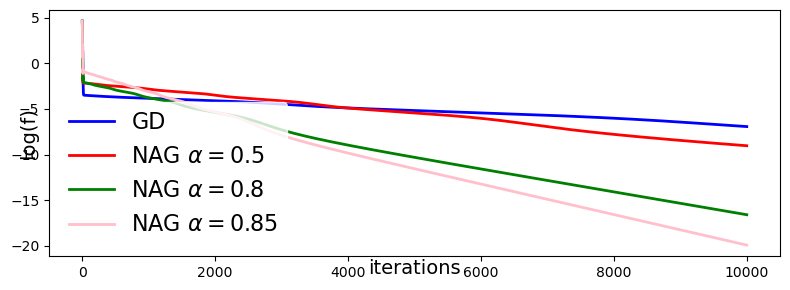

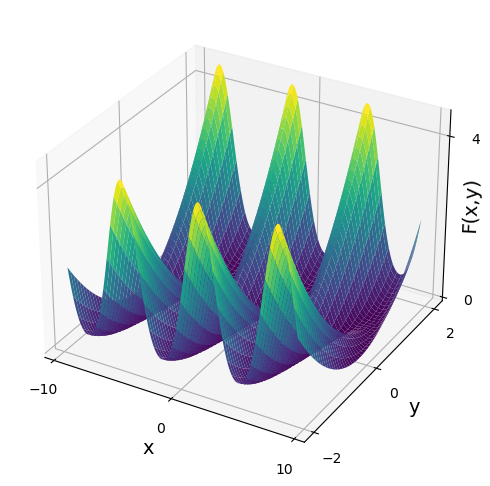

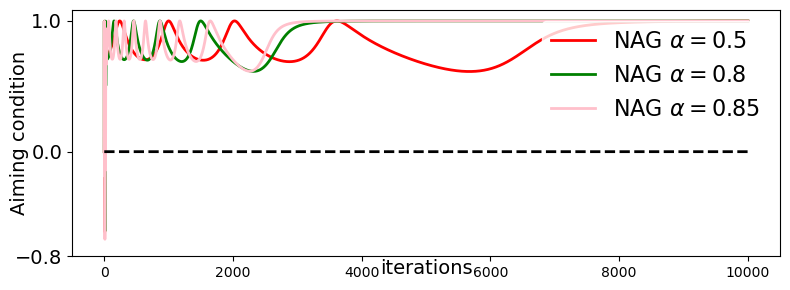

In [9]:
### MORE ITERATIONS ###

n_iter = 1*10**4
init =  np.array([-7,-15])

x_gd,f_gd = gd(init,n_iter,1/L)
x_nag_0,f_nag_0,corr_0 = nag(init,n_iter,1/L,0.5)
x_nag_1,f_nag_1,corr_1 = nag(init,n_iter,1/L,0.8)
x_nag_2,f_nag_2,corr_2 = nag(init,n_iter,1/L,0.85)
# --- FIGURE 1 : scatter des trajectoires ---
fontsize = 14
fontsize_legend = 25
plt.figure(figsize=(6,6))
plt.scatter(x_gd[0, :], x_gd[1, :], s=50,c="blue", label="GD",marker="x")
plt.scatter(x_nag_0[0, :], x_nag_0[1, :], s=40, label=r"NAG $\alpha = 0.5$", c='red',marker="+")
plt.scatter(x_nag_1[0, :], x_nag_1[1, :], s=30, label=r"NAG $\alpha = 0.8$", c='green',marker="+")
plt.scatter(x_nag_2[0, :], x_nag_2[1, :], s=10, label=r"NAG $\alpha = 0.85$", c='pink',marker="+")
plt.scatter(x_gd[0, 0], x_gd[1, 0],color="black",label="Init")
plt.xlabel("x",fontsize =fontsize,labelpad=-15)
# plt.xticks([-28,-6],fontsize =fontsize)
# plt.yticks([-15,5],fontsize =fontsize)
plt.ylabel("y",fontsize =fontsize,labelpad=-20)
# plt.title("Trajectoires GD vs NAG")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_traj_longer.pdf", dpi=300, bbox_inches="tight")

# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(np.log(f_nag_0), label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(np.log(f_nag_1),label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(np.log(f_nag_2), label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
# plt.xticks((0,1000),fontsize =fontsize)
# plt.yticks((-4,4),fontsize =fontsize)
plt.ylabel("log(f)",fontsize =fontsize,labelpad=-20)
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_fonc_longer.pdf", dpi=300, bbox_inches="tight")

x = np.linspace(-3*np.pi, 3*np.pi, 400)
y = np.linspace(-2, 2, 400)
epsilon = 0.001
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)



fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xticks([-10,0,10],fontsize =fontsize)
ax.set_yticks([-2,0,2],fontsize =fontsize)
ax.set_zticks([0,4],fontsize =fontsize)
ax.set_xlabel("x",fontsize =fontsize)
ax.set_ylabel("y",fontsize =fontsize)
ax.set_zlabel("F(x,y)",fontsize =fontsize,labelpad=-10)
plt.savefig("figures/toy_example_fig_longer.pdf", dpi=300, bbox_inches="tight")


# --- FIGURE 2 : convergence des valeurs de f ---
plt.figure(figsize=(8,3))
fontsize_legend = 16
# plt.plot(np.log(f_gd), label="GD",c="blue",lw=2)
plt.plot(corr_0, label=r"NAG $\alpha = 0.5$", c='red',lw=2)
plt.plot(corr_1,label=r"NAG $\alpha = 0.8$", c='green',lw=2)
plt.plot(corr_2, label=r"NAG $\alpha = 0.85$", c='pink',lw=2)
xx = np.arange(n_iter)
plt.plot(xx,np.zeros(n_iter)*xx,linestyle="--",color="black",lw=2)
plt.xlabel("iterations",fontsize =fontsize,labelpad=-15)
# plt.xticks((0,1000),fontsize =fontsize)
plt.yticks((-0.8,0,1),fontsize =fontsize)
plt.ylabel("Aiming condition",fontsize =fontsize,labelpad=-10)
ax = plt.gca()  # axe principal
# axins = inset_axes(ax, width="35%", height="60%", loc='lower center')

# Plot du zoom : 100 premières itérations
# axins.plot(corr_0[:100],  c='red',  lw=2)
# axins.plot(corr_1[:100],  c='green', lw=2)
# axins.plot(corr_2[:100],  c='pink',  lw=2)
# axins.plot(xx[:100],(np.zeros(n_iter)*xx)[:100],linestyle="--",color="black",lw=2)
# # Définition du domaine du zoom
# axins.set_xlim(-5, 100)
# axins.set_ylim(min(corr_0[:100].min(), corr_1[:100].min(), corr_2[:100].min())-0.1,
#                max(corr_0[:100].max(), corr_1[:100].max(), corr_2[:100].max())+0.1)

# # Retirer les labels du zoom pour éviter le fouillis
# axins.set_xticks([])
# axins.set_yticks([])

# Petits traits reliant la fenêtre au graphe principal
# mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.4")
# plt.title("Convergence en log des méthodes")
plt.legend(edgecolor=(1,1,1),fontsize=fontsize_legend)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/toy_example_corr_longer.pdf", dpi=300, bbox_inches="tight")



In [64]:
init
grad_F(init[0],init[1],epsilon)

(10.806230137302135, -14.343013401281212)

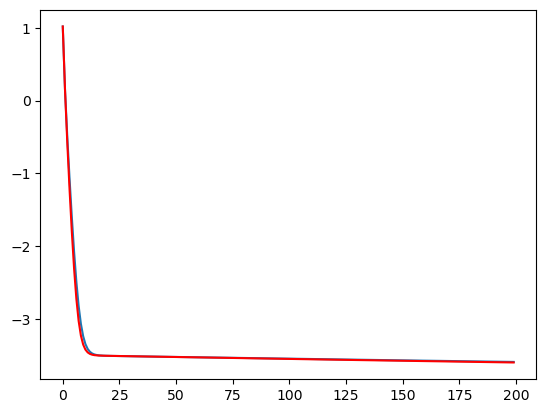

In [209]:
plt.plot(np.log(f_gd))
plt.plot(np.log(f_nag),c = "red")

In [66]:
f_nag

array([0.3038291 , 0.15856802, 1.73841666, 1.13110876, 0.43439562,
       0.78237095, 2.16312135, 0.53934417, 0.03618195, 0.99765751,
       0.33923045, 0.01657012, 0.3675107 , 0.22745518, 0.01378249,
       0.05159678, 0.07295307, 0.00897896, 0.02868735, 0.05119024,
       0.01768777, 0.0085997 , 0.01086983, 0.00857435, 0.01397657,
       0.01939004, 0.01669939, 0.01200913, 0.00906259, 0.00926585,
       0.01182329, 0.01443218, 0.01482802, 0.01307027, 0.01110969,
       0.01049261, 0.01142608, 0.01287138, 0.01356964, 0.01309862,
       0.01208328, 0.01143782, 0.01160693, 0.01229228, 0.01284311,
       0.01284597, 0.01240942, 0.01197078, 0.01188187, 0.01214469,
       0.0124789 , 0.01260343, 0.01246114, 0.01221975, 0.01209252,
       0.01215898, 0.01232761, 0.01244348, 0.01242486, 0.01231395,
       0.0122183 , 0.01221174, 0.01228207, 0.01235798, 0.01237795,
       0.01233752, 0.01228141, 0.01225794, 0.01227964, 0.0123204 ,
       0.01234404, 0.01233534, 0.01230796, 0.01228777, 0.01228

0.0005008586318265379


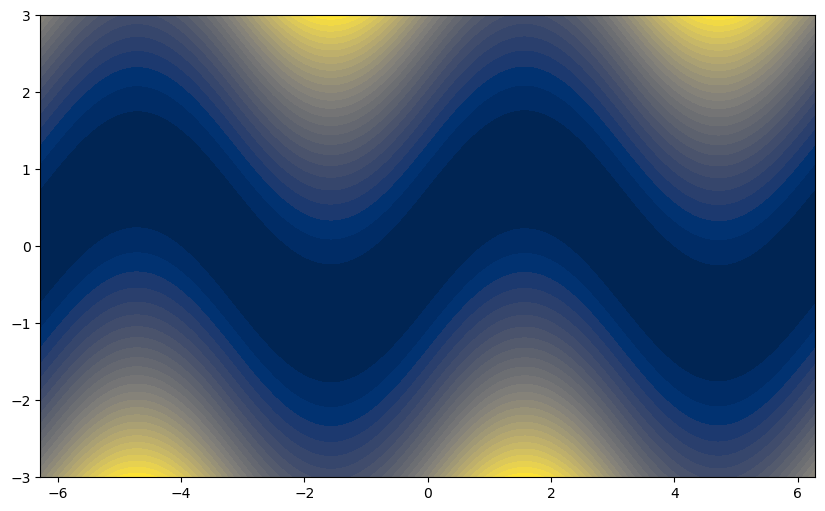

In [44]:
# Grid for the quiver
x = np.linspace(-2*np.pi, 2*np.pi, 1000)
y = np.linspace(-3, 3, 1000)
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)
U, V = grad_F(X, Y, epsilon)
# plt.quiver(X, Y, U, V, angles="xy", color="blue")

norm_x2 = X**2 + Y**2
norm_grad2 = U**2 + V**2

mask = Z > 1e-12
Q2 = np.zeros_like(X)
Q2[mask] = norm_grad2[mask] / (2 * Z[mask])

plt.figure(figsize=(10, 6))
plt.contourf(X, Y, Z, levels=30, cmap="cividis")
# plt.quiver(X, Y, U, V, angles="xy", color="blue")

# plt.xlabel("x")
# plt.ylabel("y")
# # plt.title(r"Champ de gradient de $F(x,y)=\frac{1}{2}(y-\sin x)^2 + \frac12\varepsilon x^2$")

# plt.grid(True, alpha=0.3)
print(Q2.min())
plt.show()

In [ ]:
### L_smooth

x = np.linspace(-3*np.pi, 3*np.pi, 1000)
y = np.linspace(-3, 3, 1000)
L = 0
for i in x:
    for j in y:
        val = eigen_value(i, j, epsilon)
        L = max(L,val)
    print("top :",i)

top : -9.42477796076938
top : -9.405909536423495
top : -9.38704111207761
top : -9.368172687731725
top : -9.349304263385841
top : -9.330435839039955
top : -9.311567414694071
top : -9.292698990348187
top : -9.273830566002303
top : -9.254962141656417
top : -9.236093717310533
top : -9.217225292964649
top : -9.198356868618763
top : -9.179488444272879
top : -9.160620019926995
top : -9.141751595581109
top : -9.122883171235225
top : -9.10401474688934
top : -9.085146322543455
top : -9.066277898197571
top : -9.047409473851687
top : -9.028541049505803
top : -9.009672625159917
top : -8.990804200814033
top : -8.971935776468149
top : -8.953067352122263
top : -8.934198927776379
top : -8.915330503430495
top : -8.896462079084609
top : -8.877593654738725
top : -8.85872523039284
top : -8.839856806046955
top : -8.82098838170107
top : -8.802119957355186
top : -8.783251533009302
top : -8.764383108663417
top : -8.745514684317532
top : -8.726646259971648
top : -8.707777835625762
top : -8.688909411279878
top :

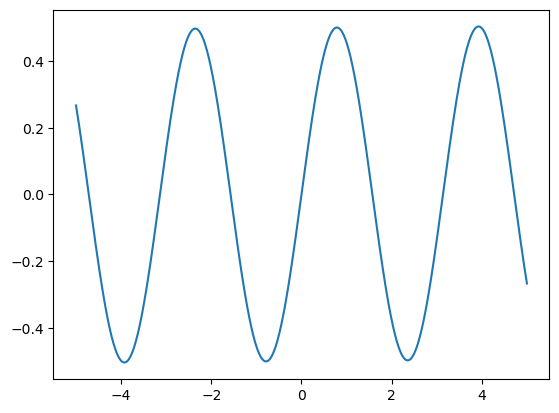

In [17]:
def test(x,y,epsilon):
    return -(y - np.sin(x)) * np.cos(x) + epsilon * x
xxx = np.linspace(-5,5,1000)
plt.plot(xxx,test(xxx,0,epsilon))

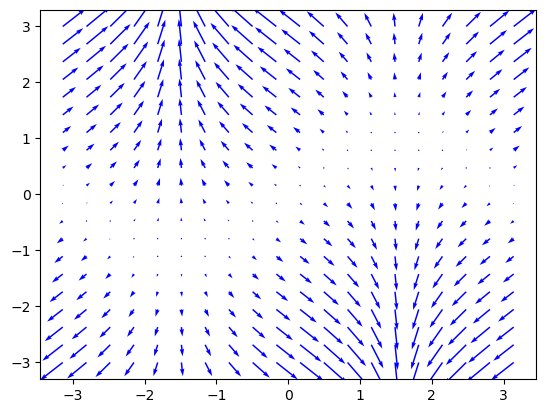

In [47]:
x = np.linspace(-np.pi, np.pi, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)
Z = F(X, Y,epsilon)
U, V = grad_F(X, Y, epsilon)
plt.quiver(X, Y, U, V, angles="xy", color="blue")


In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

trainset = CIFAR10(root="./data", train=True, download=True,
                   transform=transforms.ToTensor())

ModuleNotFoundError: No module named 'torchvision'